In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os
import numpy as np
from torchvision.models import resnet18

import torch
import torchvision
import torchvision.transforms as transforms


In [ ]:
#1

#First, download and unzip the dataset:

data_dir = "/content/drive/MyDrive/hymenoptera_data"
train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val")


In [ ]:
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

# Train transforms
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    normalize
])

# Test/Validation transforms
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    normalize
])

In [ ]:
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=val_transform)


In [ ]:
print("Classes:", train_dataset.classes)
print("Number of training images:", len(train_dataset))
print("Number of validation images:", len(val_dataset))


Classes: ['ants', 'bees']
Number of training images: 244
Number of validation images: 153


In [ ]:
print(train_dataset.classes)

['ants', 'bees']


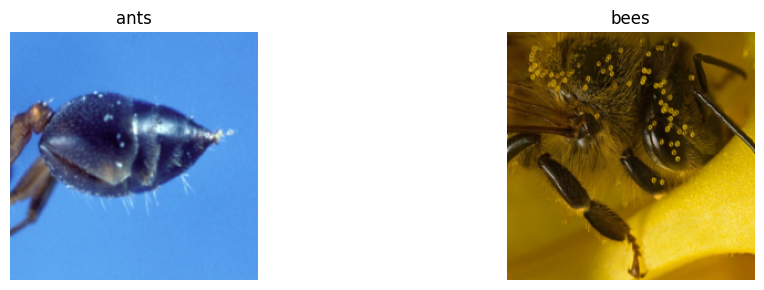

In [ ]:
#ii. Visualize an image from each of the ten classes, plot it.

import matplotlib.pyplot as plt

class_names = train_dataset.classes

# Dictionary to store one image per class
class_images = {}

# Iterate through dataset to collect one example per class
for img, label in train_dataset:
    if label not in class_images:
        class_images[label] = img  # Store the first occurrence of each class
    if len(class_images) == len(class_names):  # Stop when we have all classes
        break

# Plot the images
def unnormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return img_tensor * std + mean

# Plot the images
fig, axes = plt.subplots(1, len(class_images), figsize=(12, 3))
axes = axes.ravel()

for i, (label, img) in enumerate(class_images.items()):
    img = unnormalize(img)  # unnormalize
    img = img.permute(1, 2, 0).numpy()  # convert to HWC
    img = np.clip(img, 0, 1)  # clip values to [0,1] range
    axes[i].imshow(img)
    axes[i].set_title(class_names[label])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import torch
import torchvision.models as models

# Load pretrained ResNet-18
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)



Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 192MB/s]


In [ ]:
# Print number of input features to the final fully connected layer
num_ftrs = model.fc.in_features
print(f"Number of features output by the feature extractor: {num_ftrs}")


Number of features output by the feature extractor: 512


In [ ]:
#Replace this fully-connected layer at the end with a new fully-connected layer with 2 outputs since we are performing binary classification.

import torch.nn as nn

# Get the number of input features to the final layer
num_ftrs = model.fc.in_features

# Replace the final fully connected layer with a new one for binary classification
model.fc = nn.Linear(num_ftrs, 2)

In [ ]:
#Write a training loop for training your neural network on GPU. Use cosine decay learning rate schedule and SGD with momentum
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

def train_and_evaluate(model, train_loader, test_loader, epochs=100):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    print(f"Training on device: {device}")

    optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    train_losses, test_losses, train_accs, test_accs = [], [], [], []

    for epoch in range(epochs):
        model.train()
        correct, total, train_loss = 0, 0, 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
        train_losses.append(train_loss / len(train_loader))
        train_accs.append(100. * correct / total)

        model.eval()
        correct, total, test_loss = 0, 0, 0.0
        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                test_loss += loss.item()
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()
        test_losses.append(test_loss / len(test_loader))
        test_accs.append(100. * correct / total)

        scheduler.step()
        print(f'Epoch {epoch+1}/{epochs} | Train Acc: {train_accs[-1]:.2f}% | Test Acc: {test_accs[-1]:.2f}%')

    return train_losses, test_losses, train_accs, test_accs

In [ ]:
def run_experiments(train_loader, test_loader, epochs=30):
    results = {}

    model1 = resnet18(pretrained=True)
    model1.fc = nn.Linear(model1.fc.in_features, 10)
    print("\n[Experiment 1] Fine-tune pretrained model")
    res1 = train_and_evaluate(model1, train_loader, test_loader, epochs)
    results["Fine-tuned"] = res1

    model2 = resnet18(pretrained=True)
    for param in model2.parameters():
        param.requires_grad = False
    model2.fc = nn.Linear(model2.fc.in_features, 10)
    for param in model2.fc.parameters():
        param.requires_grad = True
    print("\n[Experiment 2] Freeze feature extractor")
    res2 = train_and_evaluate(model2, train_loader, test_loader, epochs)
    results["Frozen Features"] = res2

    model3 = resnet18(pretrained=False)
    model3.fc = nn.Linear(model3.fc.in_features, 10)
    print("\n[Experiment 3] Train from scratch")
    res3 = train_and_evaluate(model3, train_loader, test_loader, epochs)
    results["Scratch"] = res3

    return results


In [ ]:
def plot_results(results):
    for label, (train_losses, test_losses, train_accs, test_accs) in results.items():
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.plot(train_losses, label='Train Loss')
        plt.plot(test_losses, label='Test Loss')
        plt.title(f'{label} - Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(train_accs, label='Train Acc')
        plt.plot(test_accs, label='Test Acc')
        plt.title(f'{label} - Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy (%)')
        plt.legend()
        plt.show()


100%|██████████| 170M/170M [00:13<00:00, 12.8MB/s]
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



[Experiment 1] Fine-tune pretrained model
Training on device: cuda
Epoch 1/30 | Train Acc: 21.53% | Test Acc: 34.34%
Epoch 2/30 | Train Acc: 39.79% | Test Acc: 42.94%
Epoch 3/30 | Train Acc: 50.65% | Test Acc: 47.41%
Epoch 4/30 | Train Acc: 61.93% | Test Acc: 58.84%
Epoch 5/30 | Train Acc: 70.67% | Test Acc: 67.06%
Epoch 6/30 | Train Acc: 77.10% | Test Acc: 73.89%
Epoch 7/30 | Train Acc: 80.57% | Test Acc: 73.10%
Epoch 8/30 | Train Acc: 82.95% | Test Acc: 73.53%
Epoch 9/30 | Train Acc: 84.86% | Test Acc: 77.47%
Epoch 10/30 | Train Acc: 86.65% | Test Acc: 81.30%
Epoch 11/30 | Train Acc: 88.67% | Test Acc: 76.20%
Epoch 12/30 | Train Acc: 89.62% | Test Acc: 78.64%
Epoch 13/30 | Train Acc: 91.31% | Test Acc: 80.84%
Epoch 14/30 | Train Acc: 92.90% | Test Acc: 79.40%
Epoch 15/30 | Train Acc: 94.31% | Test Acc: 82.23%
Epoch 16/30 | Train Acc: 95.48% | Test Acc: 82.03%
Epoch 17/30 | Train Acc: 97.16% | Test Acc: 83.96%
Epoch 18/30 | Train Acc: 98.34% | Test Acc: 83.41%
Epoch 19/30 | Train Acc

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch 1/30 | Train Acc: 31.52% | Test Acc: 41.85%
Epoch 2/30 | Train Acc: 51.63% | Test Acc: 46.06%
Epoch 3/30 | Train Acc: 66.68% | Test Acc: 72.73%
Epoch 4/30 | Train Acc: 75.97% | Test Acc: 72.82%
Epoch 5/30 | Train Acc: 80.71% | Test Acc: 76.19%
Epoch 6/30 | Train Acc: 84.09% | Test Acc: 74.66%
Epoch 7/30 | Train Acc: 86.21% | Test Acc: 78.34%
Epoch 8/30 | Train Acc: 88.23% | Test Acc: 75.29%
Epoch 9/30 | Train Acc: 90.12% | Test Acc: 79.41%
Epoch 10/30 | Train Acc: 91.70% | Test Acc: 77.29%
Epoch 11/30 | Train Acc: 93.36% | Test Acc: 78.56%
Epoch 12/30 | Train Acc: 94.06% | Test Acc: 81.28%
Epoch 13/30 | Train Acc: 95.55% | Test Acc: 81.28%
Epoch 14/30 | Train Acc: 96.31% | Test Acc: 81.52%
Epoch 15/30 | Train Acc: 97.43% | Test Acc: 81.57%
Epoch 16/30 | Train Acc: 98.29% | Test Acc: 82.71%
Epoch 17/30 | Train Acc: 99.30% | Test Acc: 84.40%
Epoch 18/30 | Train Acc: 99.89% | Test Acc: 86.96%
Epoch 19/30 | Train Acc: 100.00% | Test Acc: 88.07%
Epoch 20/30 | Train Acc: 100.00% | Test

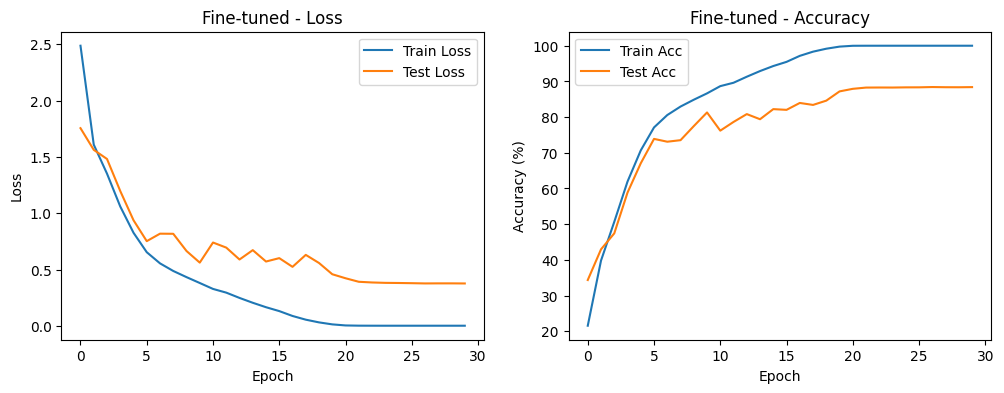

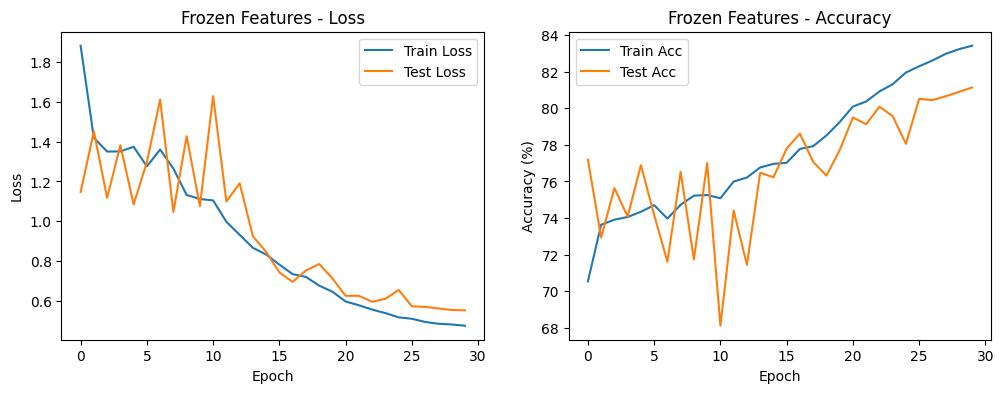

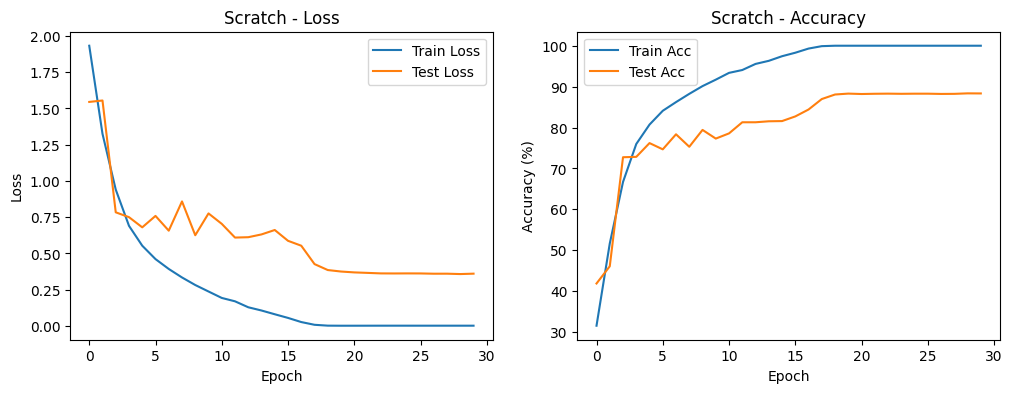

In [ ]:
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=128, shuffle=False)

results = run_experiments(train_loader, test_loader, epochs=30)
plot_results(results)


In [ ]:
#Question 2

!pip install segmentation-models-pytorch
!pip install git+https://github.com/qubvel/segmentation_models.pytorch

  Cloning https://github.com/qubvel/segmentation_models.pytorch to /tmp/pip-req-build-jy97v7l5
  Running command git clone --filter=blob:none --quiet https://github.com/qubvel/segmentation_models.pytorch /tmp/pip-req-build-jy97v7l5
  Resolved https://github.com/qubvel/segmentation_models.pytorch to commit 3ef59f4e179b3dfa6a8372b677990e4d8c4937d7
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
from segmentation_models_pytorch.datasets import SimpleOxfordPetDataset

SimpleOxfordPetDataset.download("./data")

In [ ]:
from torch.utils.data import random_split

full_dataset = SimpleOxfordPetDataset(root="./data")

total_len = len(full_dataset)
train_len = int(0.7 * total_len)
val_len = int(0.15 * total_len)
test_len = total_len - train_len - val_len

train_ds, val_ds, test_ds = random_split(full_dataset, [train_len, val_len, test_len])


In [ ]:
from torch.utils.data import DataLoader

batch_size = 8

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)


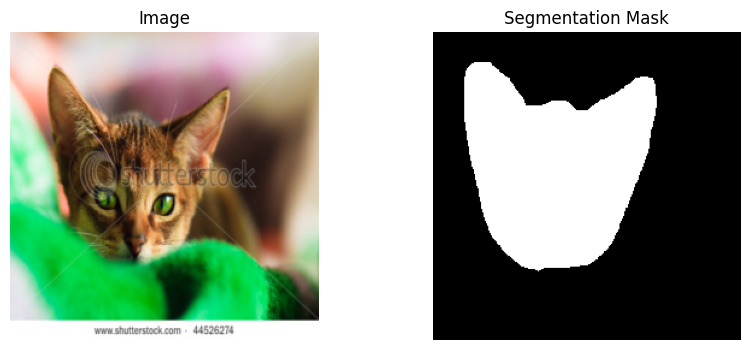

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

sample = full_dataset[0]
image = sample["image"]
mask = sample["mask"][0]

image_np = np.moveaxis(image, 0, -1)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("Image")
plt.imshow(image_np)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Segmentation Mask")
plt.imshow(mask, cmap='gray')
plt.axis('off')

plt.show()


In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset
import numpy as np

class AugmentedOxfordPetDataset(Dataset):
    def __init__(self, base_dataset, transform=None):
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        sample = self.base_dataset[idx]

        image = np.moveaxis(sample["image"], 0, -1)
        mask = sample["mask"][0]

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]
        else:
            image = torch.tensor(sample["image"], dtype=torch.float)
            mask = torch.tensor(mask, dtype=torch.float).unsqueeze(0)

        return image, mask


In [ ]:
transform_with_flip = A.Compose([
    A.HorizontalFlip(p=0.5),
    ToTensorV2()
])

transform_no_flip = A.Compose([
    ToTensorV2()
])


In [ ]:
from segmentation_models_pytorch.datasets import SimpleOxfordPetDataset
from torch.utils.data import random_split, DataLoader

base_dataset = SimpleOxfordPetDataset(root="./data")

total_len = len(base_dataset)
train_len = int(0.7 * total_len)
val_len = int(0.15 * total_len)
test_len = total_len - train_len - val_len
train_base, val_base, test_base = random_split(base_dataset, [train_len, val_len, test_len])

train_ds_with_aug = AugmentedOxfordPetDataset(train_base, transform=transform_with_flip)
train_ds_no_aug   = AugmentedOxfordPetDataset(train_base, transform=transform_no_flip)
val_ds            = AugmentedOxfordPetDataset(val_base, transform=transform_no_flip)
test_ds           = AugmentedOxfordPetDataset(test_base, transform=transform_no_flip)

train_loader = DataLoader(train_ds_with_aug, batch_size=8, shuffle=True)


val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

class FCNResNet18(nn.Module):
    def __init__(self, pretrained=True):
        super(FCNResNet18, self).__init__()
        base_model = models.resnet18(pretrained=pretrained)

        self.encoder = nn.Sequential(*list(base_model.children())[:-2])  # Output: (512, 8, 8) for 256x256 input

        self.decoder = nn.Sequential(
            nn.Conv2d(512, 1, kernel_size=1),        # Output: (1, 8, 8)
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),  # (1, 16, 16)
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),  # (1, 32, 32)
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),  # (1, 64, 64)
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),  # (1, 128, 128)
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),  # (1, 256, 256)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FCNResNet18(pretrained=True).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for imgs, masks in train_loader:
            imgs = imgs.to(device).float()
            masks = masks.to(device).float().unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs = imgs.to(device).float()
                masks = masks.to(device).float().unsqueeze(1) e
                outputs = model(imgs)
                loss = criterion(outputs, masks)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f} | Val Loss={val_loss:.4f}")

    return train_losses, val_losses


In [ ]:
def evaluate_accuracy(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, masks in test_loader:
            imgs = imgs.to(device).float()
            masks = masks.to(device).float().unsqueeze(1)  # Make shape [B, 1, H, W]
            outputs = model(imgs)
            preds = torch.sigmoid(outputs) > 0.5  # Binary mask

            correct += (preds == masks.bool()).sum().item()
            total += masks.numel()

    return correct / total


In [ ]:
def visualize_predictions(model, test_loader, num_samples=3):
    model.eval()
    count = 0
    with torch.no_grad():
        for imgs, masks in test_loader:
            imgs = imgs.to(device).float()
            masks = masks.to(device).float().unsqueeze(1)
            outputs = model(imgs)
            preds = torch.sigmoid(outputs) > 0.5

            for i in range(imgs.size(0)):
                if count >= num_samples:
                    return

                img_np = np.moveaxis(imgs[i].cpu().numpy(), 0, -1)
                img_np = img_np.astype(np.uint8)  # Correct for high-value image display
                gt_np = masks[i].cpu().squeeze().numpy()
                pred_np = preds[i].cpu().squeeze().numpy()


                plt.figure(figsize=(12, 4))

                plt.subplot(1, 3, 1)
                plt.title("Original Image")
                plt.imshow(img_np)
                plt.axis('off')

                plt.subplot(1, 3, 2)
                plt.title("Ground Truth Mask")
                plt.imshow(gt_np, cmap='gray')
                plt.axis('off')

                plt.subplot(1, 3, 3)
                plt.title("Predicted Mask")

                plt.imshow(pred_np, cmap='gray')
                plt.axis('off')

                plt.show()

                count += 1



🚀 Running: Pretrained=True, Augment=True
Epoch 1: Train Loss=0.2271 | Val Loss=0.1642
Epoch 2: Train Loss=0.1567 | Val Loss=0.1546
Epoch 3: Train Loss=0.1350 | Val Loss=0.1480
Epoch 4: Train Loss=0.1215 | Val Loss=0.1460
Epoch 5: Train Loss=0.1123 | Val Loss=0.1415
Epoch 6: Train Loss=0.1062 | Val Loss=0.1359
Epoch 7: Train Loss=0.1004 | Val Loss=0.1388
Epoch 8: Train Loss=0.0936 | Val Loss=0.1386
Epoch 9: Train Loss=0.0890 | Val Loss=0.1395
Epoch 10: Train Loss=0.0865 | Val Loss=0.1411


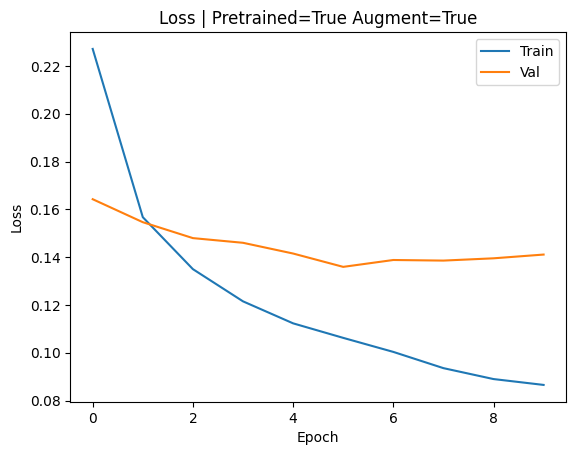

🖼️ Visualizing test predictions for Pretrained=True | Augmented=True


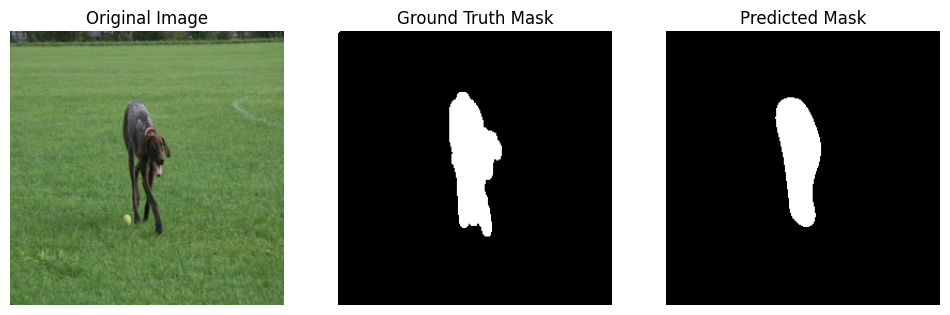

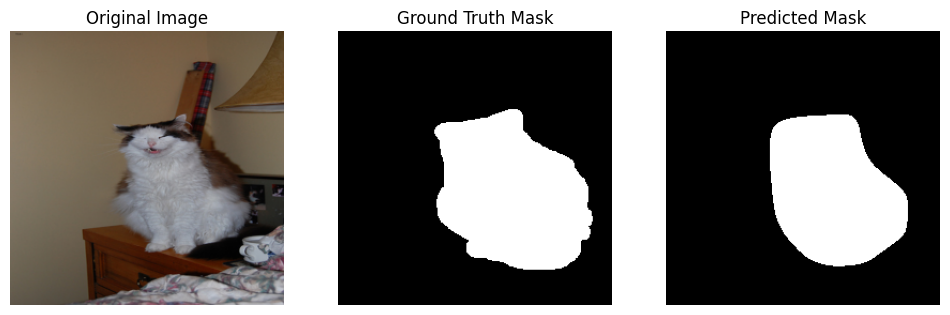

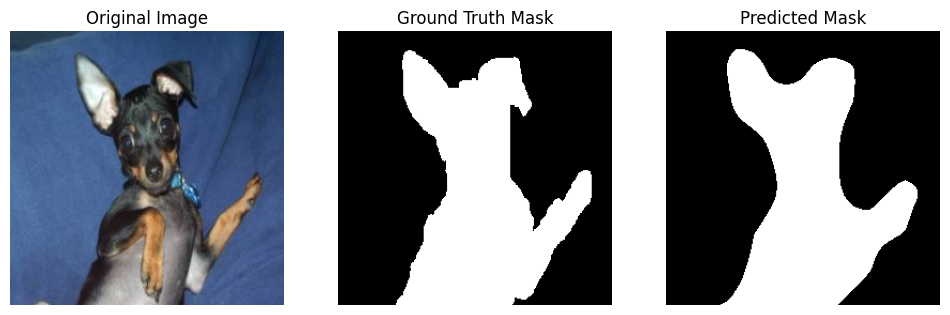


🚀 Running: Pretrained=True, Augment=False
Epoch 1: Train Loss=0.2234 | Val Loss=0.1691
Epoch 2: Train Loss=0.1451 | Val Loss=0.1589
Epoch 3: Train Loss=0.1217 | Val Loss=0.1487
Epoch 4: Train Loss=0.1050 | Val Loss=0.1495
Epoch 5: Train Loss=0.0963 | Val Loss=0.1479
Epoch 6: Train Loss=0.0902 | Val Loss=0.1492
Epoch 7: Train Loss=0.0842 | Val Loss=0.1497
Epoch 8: Train Loss=0.0798 | Val Loss=0.1496
Epoch 9: Train Loss=0.0761 | Val Loss=0.1520
Epoch 10: Train Loss=0.0730 | Val Loss=0.1536


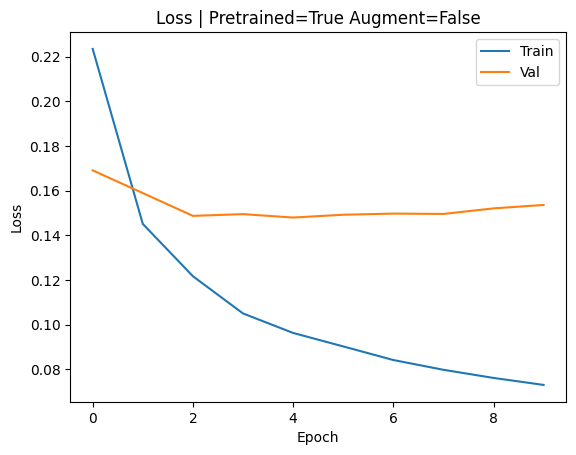

🖼️ Visualizing test predictions for Pretrained=True | Augmented=False


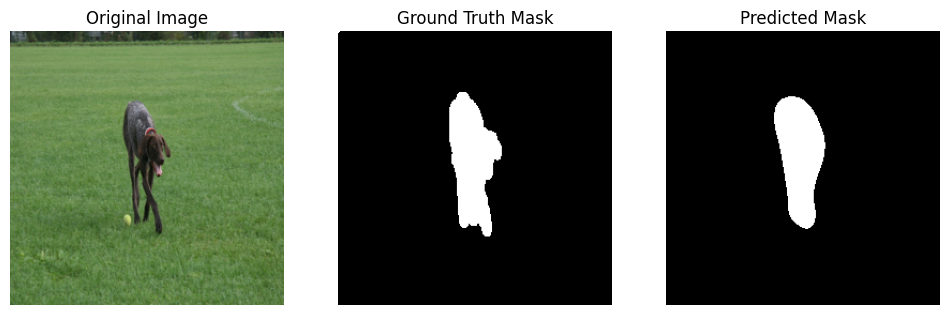

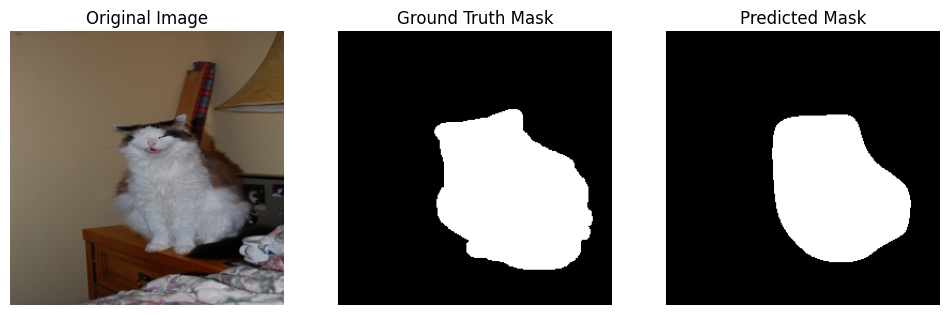

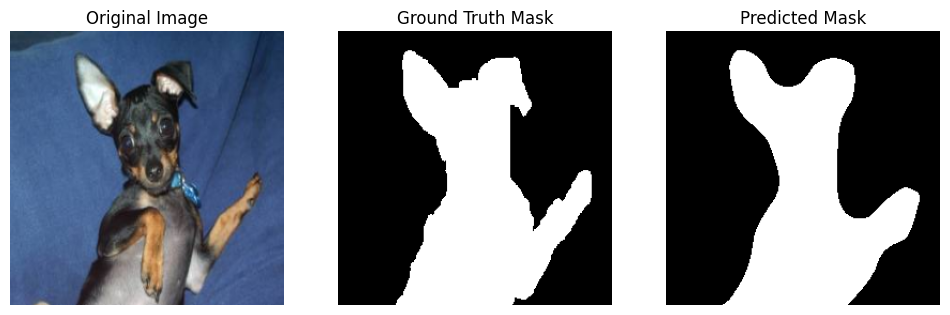


🚀 Running: Pretrained=False, Augment=True


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch 1: Train Loss=0.4703 | Val Loss=0.4504
Epoch 2: Train Loss=0.3853 | Val Loss=0.3928
Epoch 3: Train Loss=0.3354 | Val Loss=0.3276
Epoch 4: Train Loss=0.3033 | Val Loss=0.3084
Epoch 5: Train Loss=0.2771 | Val Loss=0.3038
Epoch 6: Train Loss=0.2558 | Val Loss=0.3058
Epoch 7: Train Loss=0.2390 | Val Loss=0.2955
Epoch 8: Train Loss=0.2202 | Val Loss=0.2952
Epoch 9: Train Loss=0.2022 | Val Loss=0.3032
Epoch 10: Train Loss=0.1835 | Val Loss=0.2993


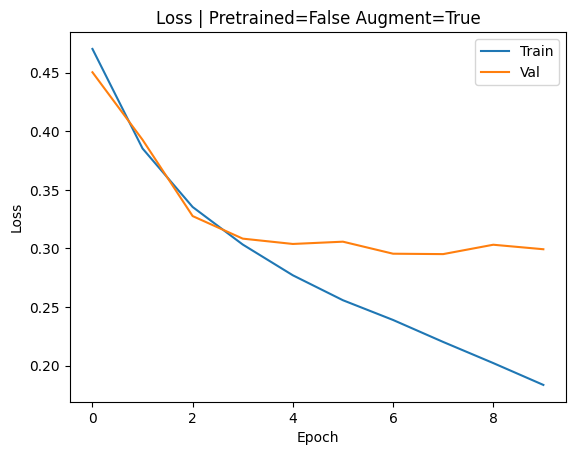

🖼️ Visualizing test predictions for Pretrained=False | Augmented=True


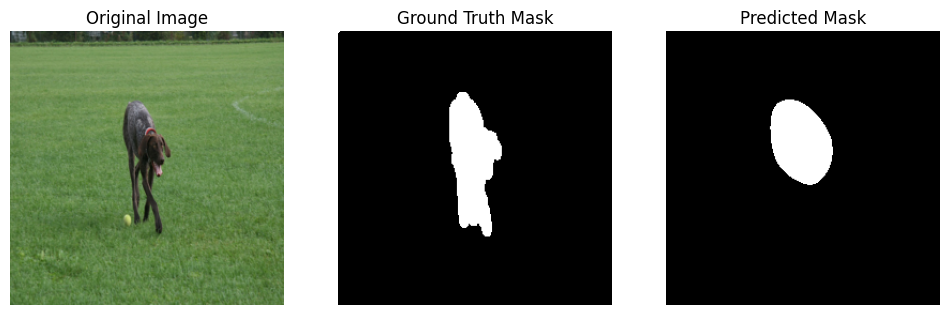

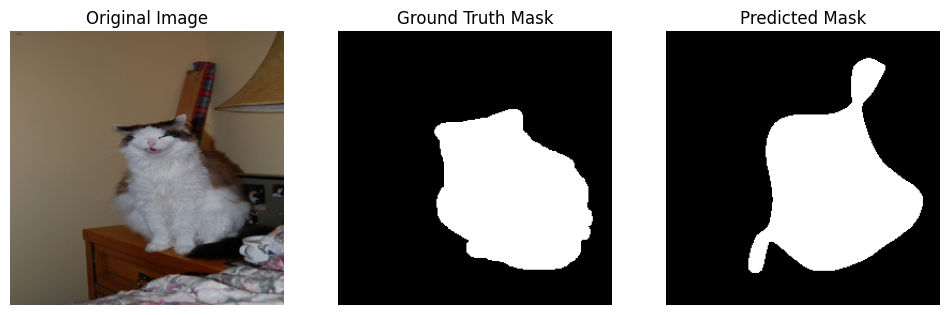

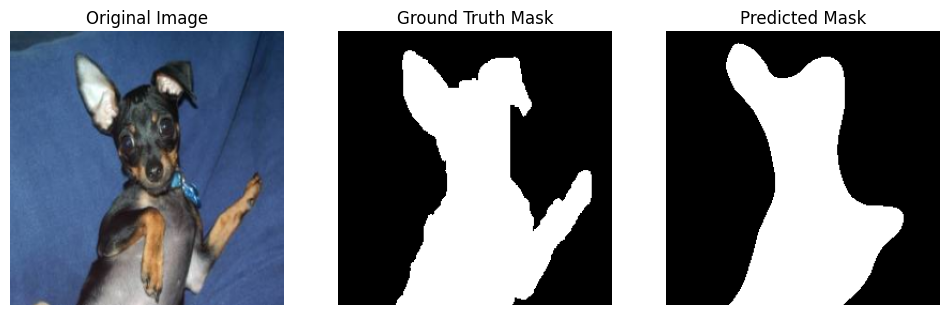


🚀 Running: Pretrained=False, Augment=False
Epoch 1: Train Loss=0.4764 | Val Loss=0.4208
Epoch 2: Train Loss=0.3823 | Val Loss=0.3897
Epoch 3: Train Loss=0.3239 | Val Loss=0.3353
Epoch 4: Train Loss=0.2840 | Val Loss=0.3759
Epoch 5: Train Loss=0.2369 | Val Loss=0.3192
Epoch 6: Train Loss=0.1980 | Val Loss=0.3601
Epoch 7: Train Loss=0.1687 | Val Loss=0.3583
Epoch 8: Train Loss=0.1561 | Val Loss=0.3310
Epoch 9: Train Loss=0.1450 | Val Loss=0.3309
Epoch 10: Train Loss=0.1309 | Val Loss=0.3323


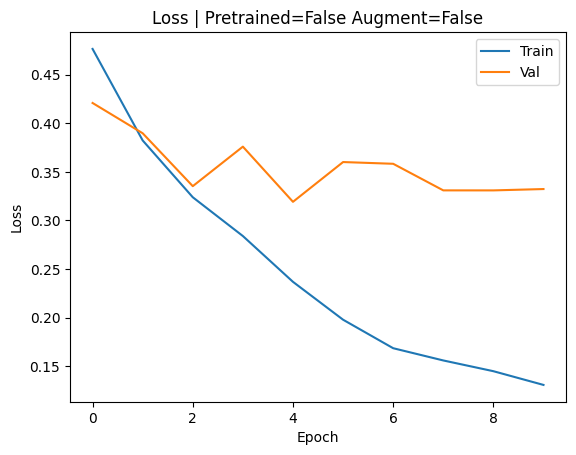

🖼️ Visualizing test predictions for Pretrained=False | Augmented=False


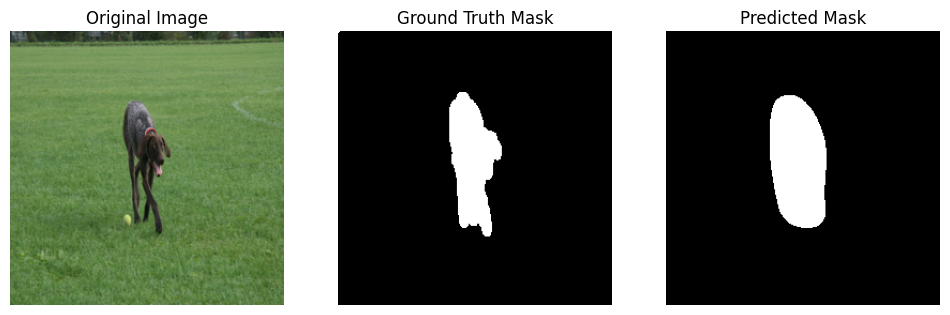

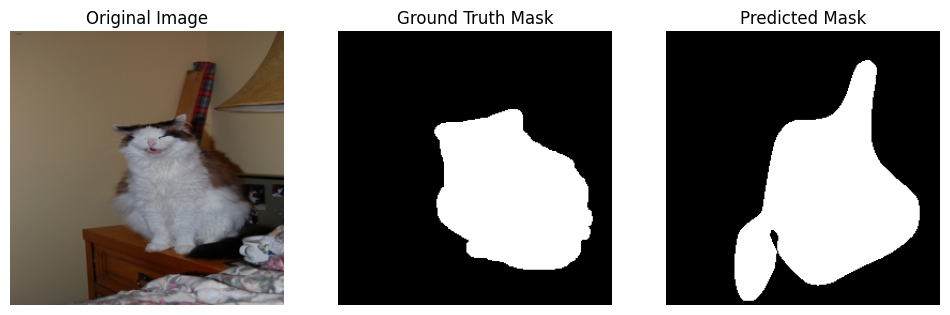

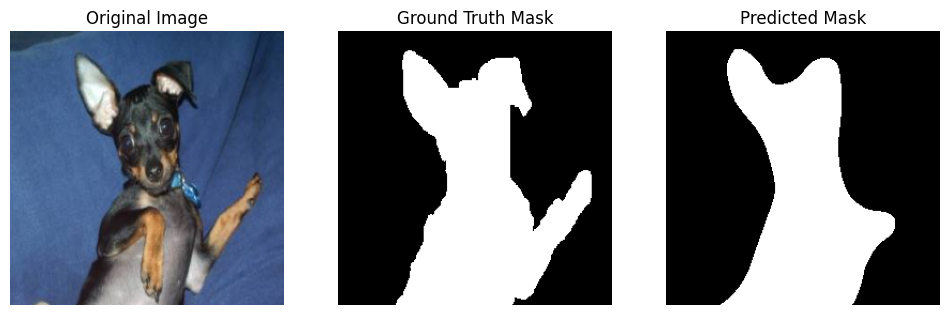

In [ ]:
import time
import matplotlib.pyplot as plt

# Define combinations to test
configs = [
    {"pretrained": True,  "augment": True},
    {"pretrained": True,  "augment": False},
    {"pretrained": False, "augment": True},
    {"pretrained": False, "augment": False},
]

results = []

for cfg in configs:
    print(f"\n🚀 Running: Pretrained={cfg['pretrained']}, Augment={cfg['augment']}")

    # Load new model
    model = FCNResNet18(pretrained=cfg["pretrained"]).to(device)

    # Choose dataset
    train_ds = train_ds_with_aug if cfg["augment"] else train_ds_no_aug
    train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)

    # Loss and optimizer
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    # Train model
    start_time = time.time()
    train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10)
    runtime = time.time() - start_time

    # Evaluate test accuracy
    test_acc = evaluate_accuracy(model, test_loader)

    # Save model
    model_name = f"model_pre_{cfg['pretrained']}_aug_{cfg['augment']}.pth"
    torch.save(model.state_dict(), model_name)

    # Store results
    results.append({
        "Pretrained": cfg["pretrained"],
        "Augmented": cfg["augment"],
        "Val Loss": val_losses[-1],
        "Test Accuracy": test_acc,
        "Time (s)": round(runtime, 2)
    })

    # Plot losses
    plt.plot(train_losses, label='Train')
    plt.plot(val_losses, label='Val')
    plt.title(f"Loss | Pretrained={cfg['pretrained']} Augment={cfg['augment']}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    # Visualize predictions
    print(f"🖼️ Visualizing test predictions for Pretrained={cfg['pretrained']} | Augmented={cfg['augment']}")
    visualize_predictions(model, test_loader, num_samples=3)
